In [1]:
# Cell 1: Comprehensive Imports
import warnings, re, os, json
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Download necessary NLTK components
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger', 'punkt', 'wordnet']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print("Environment ready ✓")

Environment ready ✓


Sentiment Analysis

In [2]:
# Cell 3: Preprocessing Logic
df_dashen = pd.read_csv('../data/processed/dashen_bank_reviews_clean.csv')
df_boa = pd.read_csv('../data/processed/boa_bank_reviews_clean.csv')
df_cbe = pd.read_csv('../data/processed/cbe_bank_reviews_clean.csv')

# df_clean = pd.concat([dashen, boa, cbe], ignore_index=True)
def modular_nlp_pipeline(text):
    # Combine datasets
    # 1. Cleaning
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Stop-word removal & Lemmatization
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    processed = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(processed)

# Apply cleaning to Dashen bank data
print("Running modular preprocessing...")
df_dashen['clean_text'] = df_dashen['review'].apply(modular_nlp_pipeline)

# Drop invalid/too short reviews
df_clean_data = df_dashen[df_dashen['clean_text'].str.len() > 2].copy()
print(f"Final cleaned dataset size: {len(df_dashen)}")


# Apply cleaning to BOA bank data
print("Running modular preprocessing...")
df_boa['clean_text'] = df_boa['review'].apply(modular_nlp_pipeline)

# Drop invalid/too short reviews
df_clean_data = df_boa[df_boa['clean_text'].str.len() > 2].copy()
print(f"Final cleaned dataset size: {len(df_boa)}")


# Apply cleaning to CBE bank data
print("Running modular preprocessing...")
df_cbe['clean_text'] = df_cbe['review'].apply(modular_nlp_pipeline)

# Drop invalid/too short reviews
df_clean_data = df_cbe[df_cbe['clean_text'].str.len() > 2].copy()
print(f"Final cleaned dataset size: {len(df_cbe)}")

Running modular preprocessing...
Final cleaned dataset size: 500
Running modular preprocessing...
Final cleaned dataset size: 500
Running modular preprocessing...
Final cleaned dataset size: 500


In [3]:
from transformers import pipeline

# CSV paths


def classify_review(df_clean,name):

    try:
        # Load CSV
        # df_clean = pd.read_csv(csv_path)

        # Load transformer model
        sent_model = pipeline("sentiment-analysis",model="distilbert-base-uncased-finetuned-sst-2-english")

        # Store results
        transformer_results = []

        # Review column name
        reviews = df_clean['review'].astype(str).tolist()

        # Batch size
        batch_size = 16

        # Process reviews in batches
        for i in range(0, len(reviews), batch_size):

            batch = reviews[i:i + batch_size]

            results = sent_model(batch)

            transformer_results.extend(results)

        # Save labels
        df_clean['transformer_sentiment_label'] = [
            p['label'] for p in transformer_results
        ]

        # Save scores
        df_clean['transformer_sentiment_score'] = [
            p['score'] if p['label'] == 'POSITIVE'
            else -p['score']
            for p in transformer_results
        ]

        # Display distribution
        print(f"\nTransformer Sentiment Distribution of {name}:")
        print(
            df_clean['transformer_sentiment_label']
            .value_counts(normalize=True)
            .round(2)
        )

        return df_clean

    except Exception as e:
        print(f"Transformer skipped: {e}")


# Run classification
dashen_cleaned_df = classify_review(df_dashen,'Dashen Bank')
boa_cleaned_df=classify_review(df_boa,'BOA')
cbe_cleaned_df=classify_review(df_cbe,'CBE')
# print(dashen_df.head())

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 368.42it/s]



Transformer Sentiment Distribution of Dashen Bank:
transformer_sentiment_label
POSITIVE    0.64
NEGATIVE    0.36
Name: proportion, dtype: float64


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 647.38it/s]



Transformer Sentiment Distribution of BOA:
transformer_sentiment_label
POSITIVE    0.53
NEGATIVE    0.47
Name: proportion, dtype: float64


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1068.27it/s]



Transformer Sentiment Distribution of CBE:
transformer_sentiment_label
POSITIVE    0.68
NEGATIVE    0.32
Name: proportion, dtype: float64


In [4]:

dashen_cleaned_df['vader_compound'] = dashen_cleaned_df['review'].apply(lambda x: sia.polarity_scores(x)['compound'])
boa_cleaned_df['vader_compound'] = boa_cleaned_df['review'].apply(lambda x: sia.polarity_scores(x)['compound'])
cbe_cleaned_df['vader_compound'] = cbe_cleaned_df['review'].apply(lambda x: sia.polarity_scores(x)['compound'])

def get_label(s):
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')
#Dashen bank
dashen_cleaned_df['sentiment'] = dashen_cleaned_df['vader_compound'].apply(get_label)
print("VADER Distribution of Dashen bank:\n", dashen_cleaned_df['sentiment'].value_counts(normalize=True).round(2))

#BOA bank
boa_cleaned_df['sentiment'] = boa_cleaned_df['vader_compound'].apply(get_label)
print("VADER Distribution of BOA:\n", boa_cleaned_df['sentiment'].value_counts(normalize=True).round(2))

#CBE bank
cbe_cleaned_df['sentiment'] = cbe_cleaned_df['vader_compound'].apply(get_label)
print("VADER Distribution of CBE:\n", cbe_cleaned_df['sentiment'].value_counts(normalize=True).round(2))

VADER Distribution of Dashen bank:
 sentiment
positive    0.64
neutral     0.23
negative    0.13
Name: proportion, dtype: float64
VADER Distribution of BOA:
 sentiment
positive    0.51
neutral     0.31
negative    0.17
Name: proportion, dtype: float64
VADER Distribution of CBE:
 sentiment
positive    0.67
neutral     0.23
negative    0.10
Name: proportion, dtype: float64


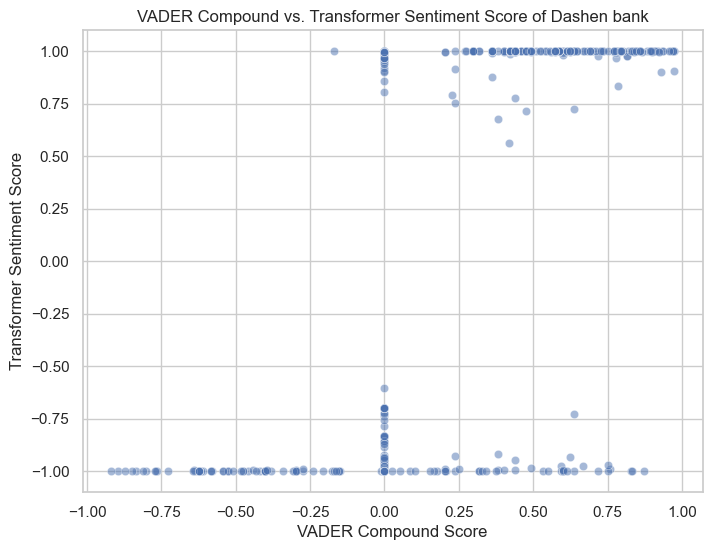

<Figure size 1100x500 with 0 Axes>

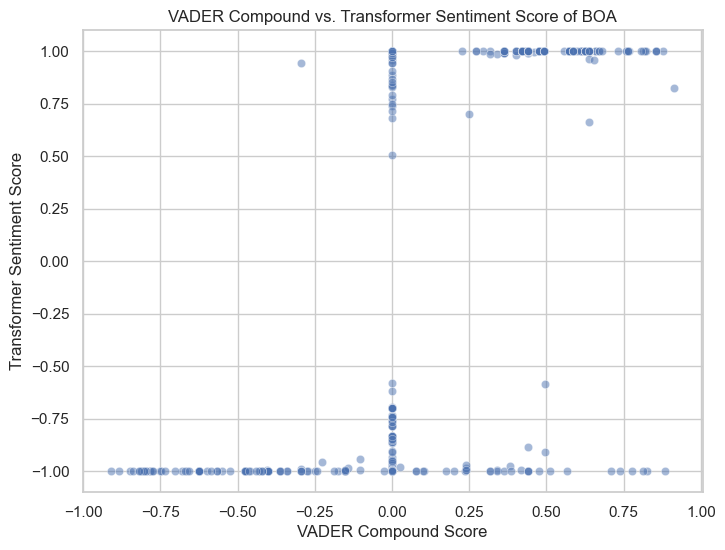

<Figure size 1100x500 with 0 Axes>

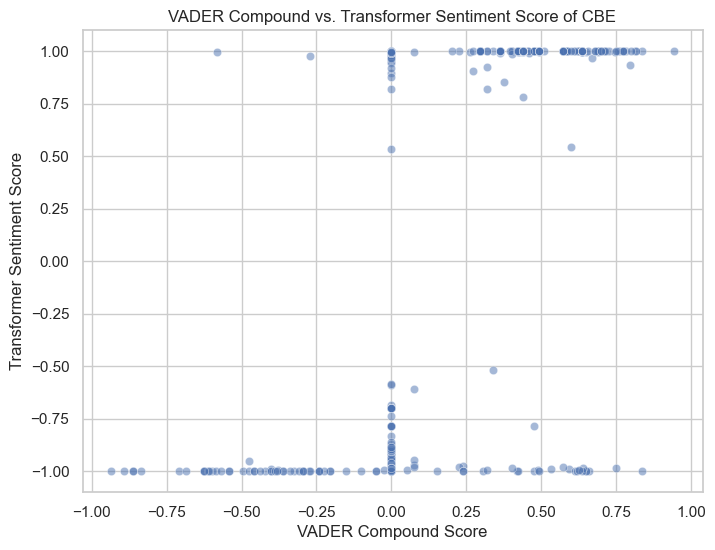

<Figure size 1100x500 with 0 Axes>

In [5]:
# comparison between VADER vs Transformers
def compare_models(df_clean,name):
    if 'transformer_sentiment_score' not in df_clean.columns:
        print("Transformer sentiment scores not available for comparison.")
    else:
        
        # Create a DataFrame for correlation
        sentiment_scores = df_clean[['vader_compound', 'transformer_sentiment_score']]

        # Calculate the correlation matrix
        # correlation_matrix = sentiment_scores.corr()

        # plt.figure(figsize=(8, 6))
        # sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
        # plt.title('Correlation Matrix of Sentiment Scores (VADER, Transformer)')
        # plt.show()

        plt.figure(figsize=(8, 6))

        sns.scatterplot(data=df_clean, x='vader_compound', y='transformer_sentiment_score', alpha=0.5)

        plt.title(f'VADER Compound vs. Transformer Sentiment Score of {name}')
        plt.xlabel('VADER Compound Score')
        plt.ylabel('Transformer Sentiment Score')

        plt.show()

        plt.tight_layout()
        plt.show()
        
compare_models(dashen_cleaned_df,'Dashen bank')
compare_models(boa_cleaned_df,'BOA')
compare_models(cbe_cleaned_df,'CBE')

rating,1,2,3,4,5
bank,,,,,
BOA Bank,-0.170079,0.055212,0.116389,0.301505,0.347318
CBE Bank,-0.025393,0.220575,-0.050770,0.202656,0.387354
Dashen Bank,-0.150357,0.034589,0.273067,0.363415,0.432832


rating,1,2,3,4,5
bank,,,,,
BOA Bank,-0.828098,-0.563670,-0.222430,0.051178,0.608384
CBE Bank,-0.555399,-0.665565,-0.382954,-0.039735,0.726924
Dashen Bank,-0.771981,-0.571110,-0.542542,0.390211,0.725755


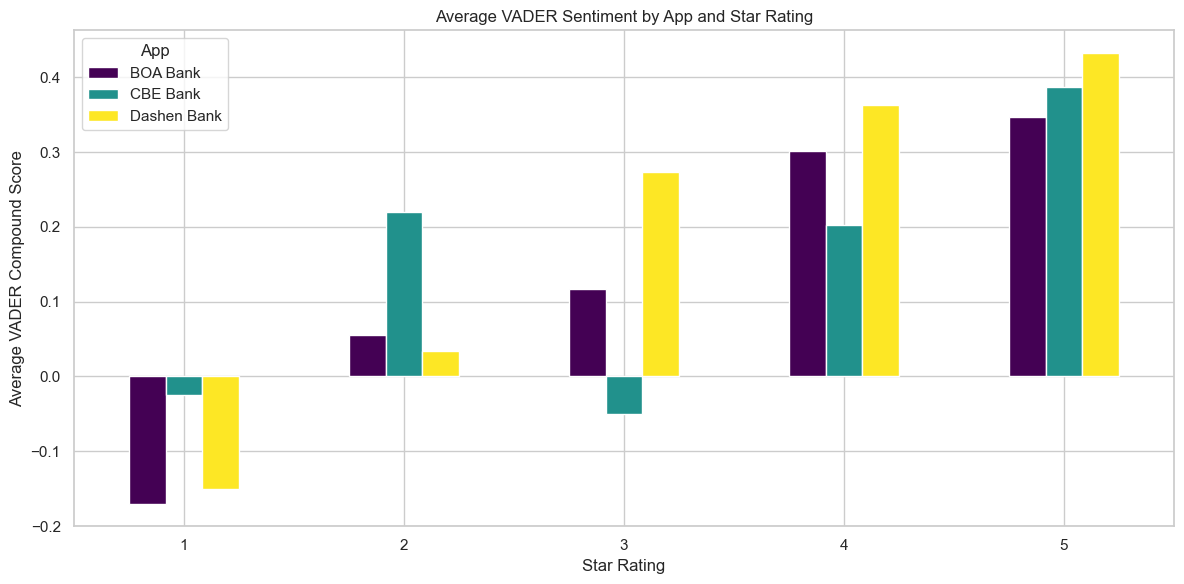

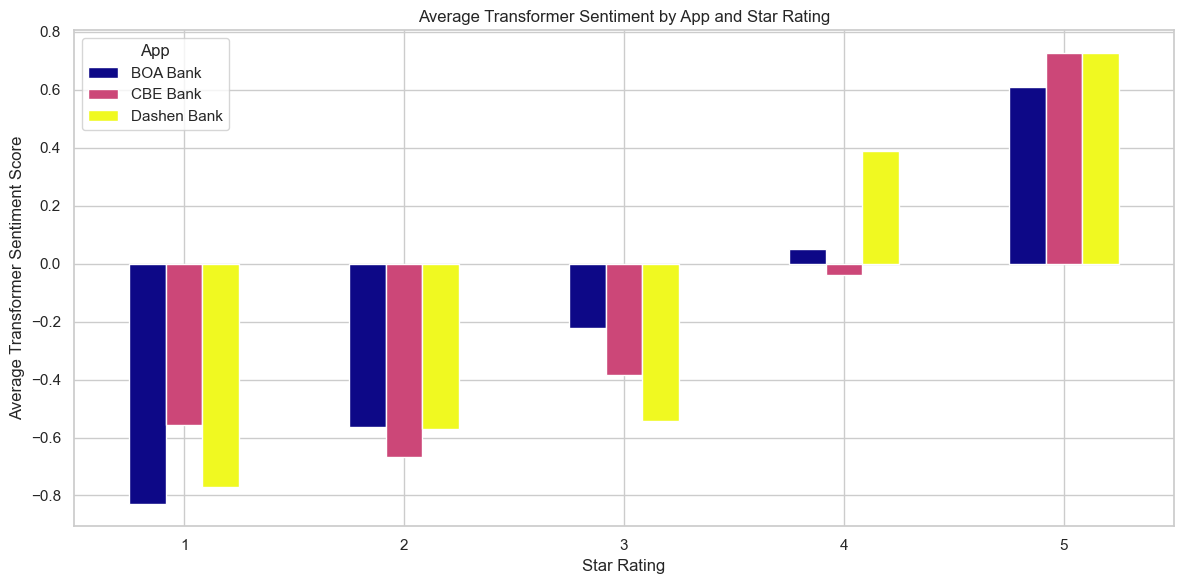

In [6]:
# Aggregate VADER sentiment scores by app and star rating
final_cleaned_df = pd.concat([dashen_cleaned_df, boa_cleaned_df, cbe_cleaned_df], ignore_index=True)
def aggregate_sentiment_scores(df_clean):
    vader_agg_sentiment = df_clean.groupby(['bank', 'rating'])['vader_compound'].mean().unstack()
    display(vader_agg_sentiment)

    # # Aggregate TextBlob polarity scores by app and star rating
    # tb_agg_sentiment = df_clean.groupby(['app', 'rating'])['tb_polarity'].mean().unstack()
    # display(tb_agg_sentiment)

    # Aggregate Transformer sentiment scores by app and star rating
    transformer_agg_sentiment = df_clean.groupby(['bank', 'rating'])['transformer_sentiment_score'].mean().unstack()
    display(transformer_agg_sentiment)

    # Visualize VADER sentiment by app and rating
    vader_agg_sentiment.T.plot(kind='bar', figsize=(12, 6), colormap='viridis')
    plt.title('Average VADER Sentiment by App and Star Rating')
    plt.xlabel('Star Rating')
    plt.ylabel('Average VADER Compound Score')
    plt.xticks(rotation=0)
    plt.legend(title='App')
    plt.tight_layout()
    plt.show()

    # Visualize Transformer sentiment by app and rating
    transformer_agg_sentiment.T.plot(kind='bar', figsize=(12, 6), colormap='plasma')
    plt.title('Average Transformer Sentiment by App and Star Rating')
    plt.xlabel('Star Rating')
    plt.ylabel('Average Transformer Sentiment Score')
    plt.xticks(rotation=0)
    plt.legend(title='App')
    plt.tight_layout()
    plt.show()
    
aggregate_sentiment_scores(final_cleaned_df)

Thematic Analysis

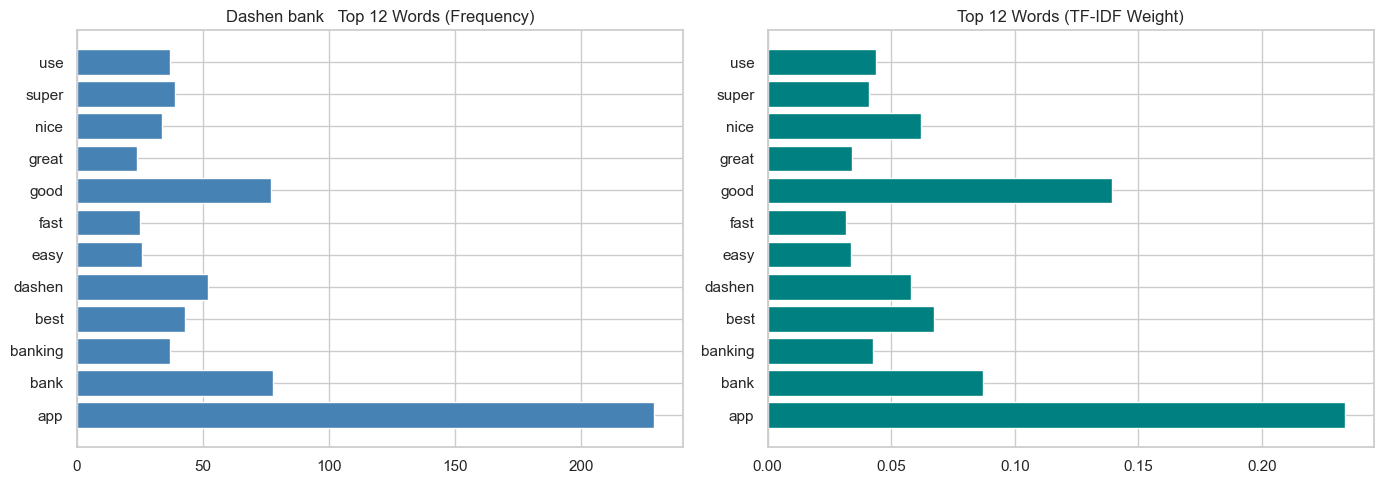

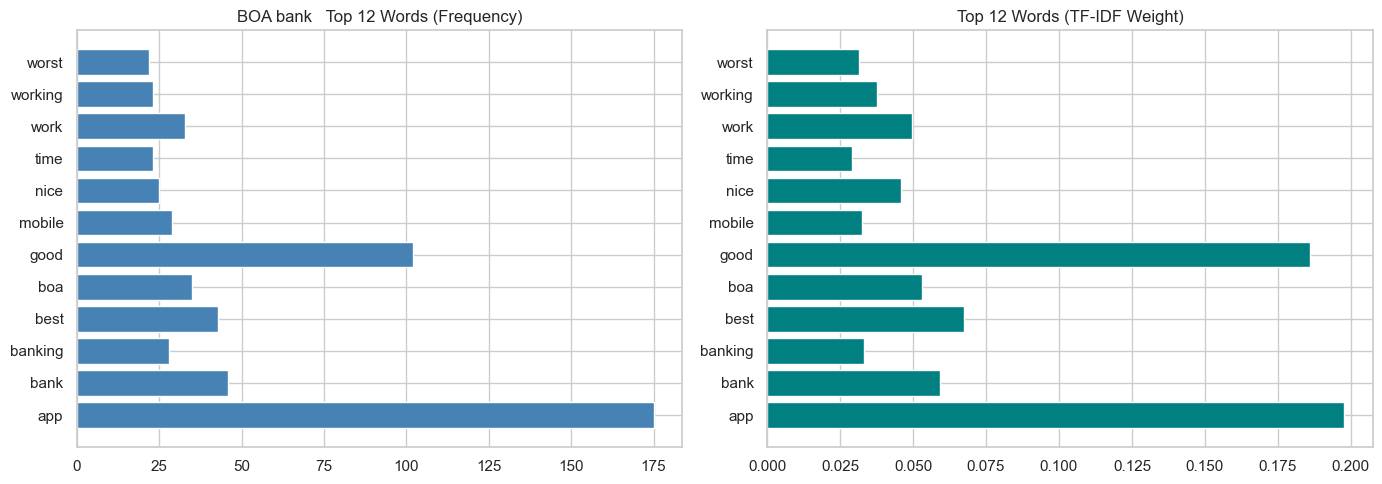

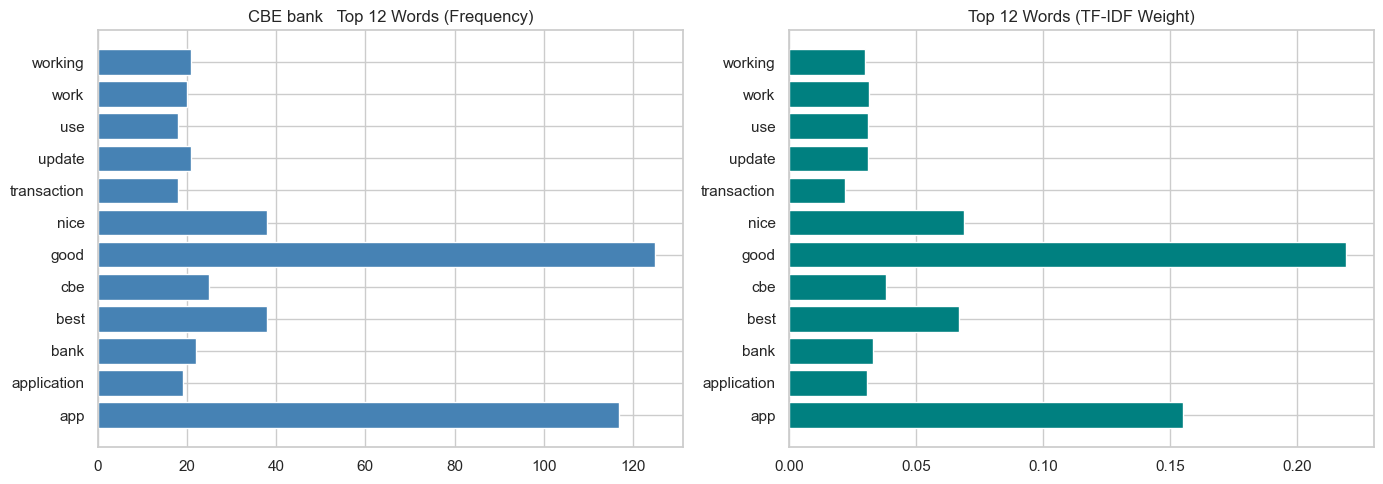

In [7]:
#Extract significant keywords
# Frequency (BoW) vs TF-IDF
def keyword_extraction(df_clean,name):
    tfidf_vec = TfidfVectorizer(max_features=12, stop_words='english')
    X_tfidf = tfidf_vec.fit_transform(df_clean['clean_text'])

    cv_vec = CountVectorizer(max_features=12, stop_words='english')
    X_cv = cv_vec.fit_transform(df_clean['clean_text'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(cv_vec.get_feature_names_out(), X_cv.toarray().sum(axis=0), color='steelblue')
    axes[0].set_title(f'{name}   Top 12 Words (Frequency)')

    axes[1].barh(tfidf_vec.get_feature_names_out(), X_tfidf.toarray().mean(axis=0), color='teal')
    axes[1].set_title('Top 12 Words (TF-IDF Weight)')

    plt.tight_layout(); plt.show()
    
keyword_extraction(dashen_cleaned_df,'Dashen bank')
keyword_extraction(boa_cleaned_df,'BOA bank')
keyword_extraction(cbe_cleaned_df,'CBE bank')



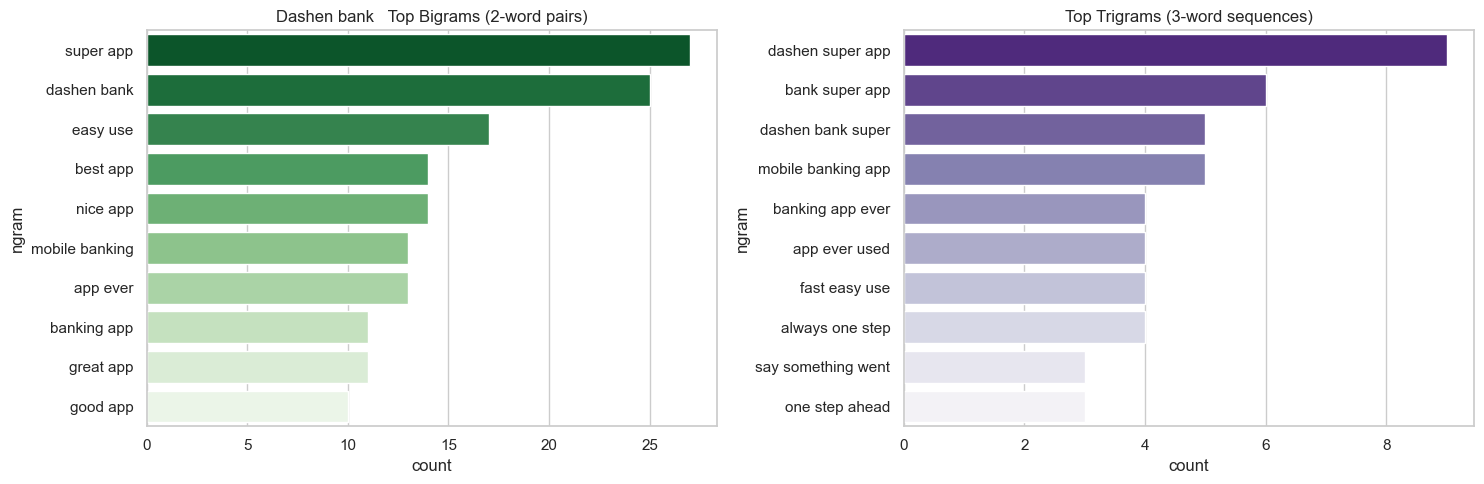

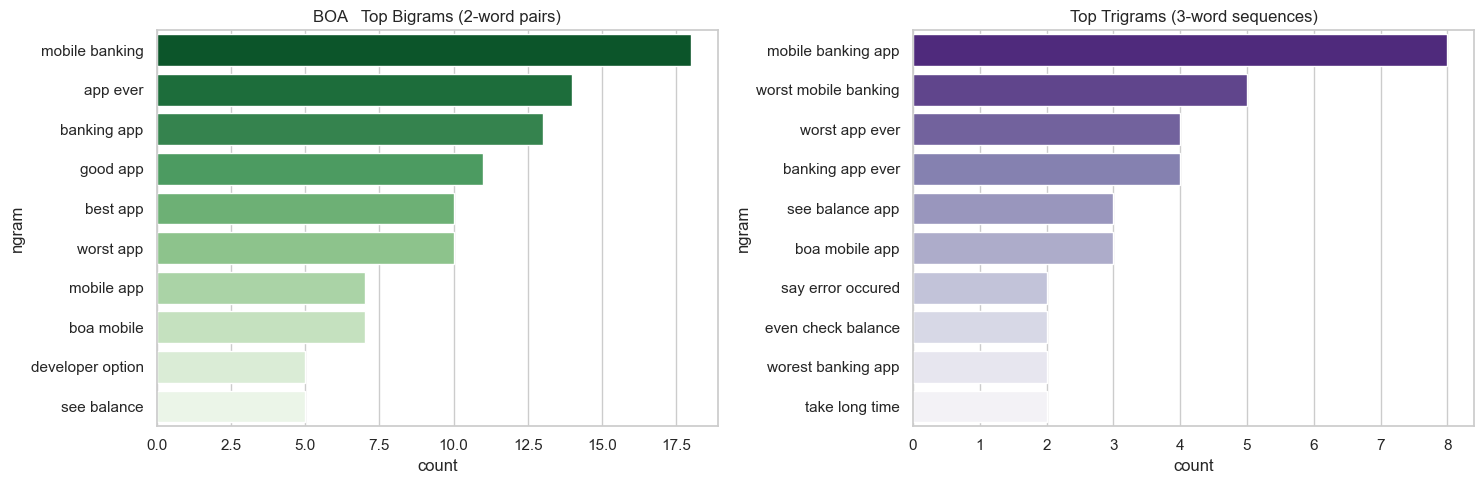

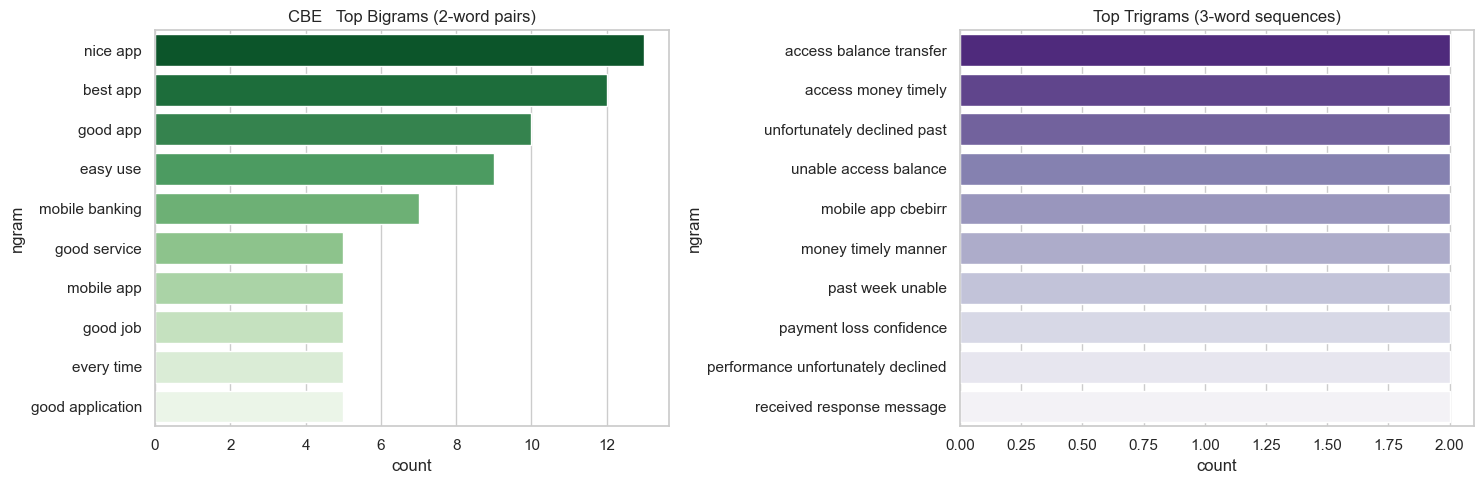

In [8]:
#n-gram using TF-IDF
def get_top_ngrams(corpus, n, k=10):
    vec = CountVectorizer(ngram_range=(n,n), max_features=100)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    return pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(k)

#Dashen bank
def ngram_visualization(df_clean,name):
    bi = get_top_ngrams(df_clean['clean_text'], 2)
    tri = get_top_ngrams(df_clean['clean_text'], 3)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
    axes[0].set_title(f'{name}   Top Bigrams (2-word pairs)')
    sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
    axes[1].set_title('Top Trigrams (3-word sequences)')
    plt.tight_layout(); plt.show()
    
ngram_visualization(dashen_cleaned_df,'Dashen bank')
ngram_visualization(boa_cleaned_df,'BOA')
ngram_visualization(cbe_cleaned_df,'CBE')


## Theme Grouping Logic — BOA Bank Reviews

### 1. App Performance & Reliability
Keywords: working, work, time

Reasoning:
These keywords relate to how well the banking application functions, including responsiveness, uptime, and operational reliability. Users are discussing whether the app works properly and performs efficiently over time.

---

### 2. User Experience & Satisfaction
Keywords: nice, good, best, worst

Reasoning:
These terms reflect overall customer sentiment and satisfaction with the banking app experience. Positive words indicate approval and usability satisfaction, while negative terms highlight dissatisfaction or frustration.

---

### 3. Mobile Banking Services
Keywords: mobile, banking, app, application

Reasoning:
These keywords directly describe the digital banking platform and mobile banking functionality. They represent discussions centered on the app as a service channel.

---

### 4. Brand & Bank Identity
Keywords: dashen , super, boa, bank

Reasoning:
These terms identify the institution itself and indicate that users are referring specifically to the BOA banking service and brand reputation.

Pipeline

In [ ]:
combined_df = pd.concat([dashen_cleaned_df, boa_cleaned_df, cbe_cleaned_df], ignore_index=True)

# Create filtered dataframe
filtered_df = pd.DataFrame({
    "review_text": combined_df["review"],
    "sentiment_label": combined_df["transformer_sentiment_label"],
    "sentiment_score": combined_df["transformer_sentiment_score"],
    "identified_theme": combined_df["sentiment"]
})

# Create review_id
filtered_df.insert(0, "review_id", range(1, len(filtered_df) + 1))

# Save to CSV
filtered_df.to_csv("../data/processed/combined_filtered_reviews.csv", index=False)

print(filtered_df.head())